In [1]:
import nrrd
import os
import numpy as np
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
from AIAH_utility.viewer import BasicViewer
import nibabel as nib
import SimpleITK as sitk
import numpy as np
from scipy.ndimage import binary_dilation


In [2]:
mask_path = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/prostate_mask'
files = os.listdir(mask_path)
smooth_mask_path = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/smooth_prostate_mask'
file = '71525088_12910281.nrrd'#files[0]
mask, _ = nrrd.read(os.path.join(mask_path, file))
smooth_mask, _ = nrrd.read(os.path.join(smooth_mask_path, file))
t2, _ = nrrd.read(os.path.join('/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/t2_registered', file))

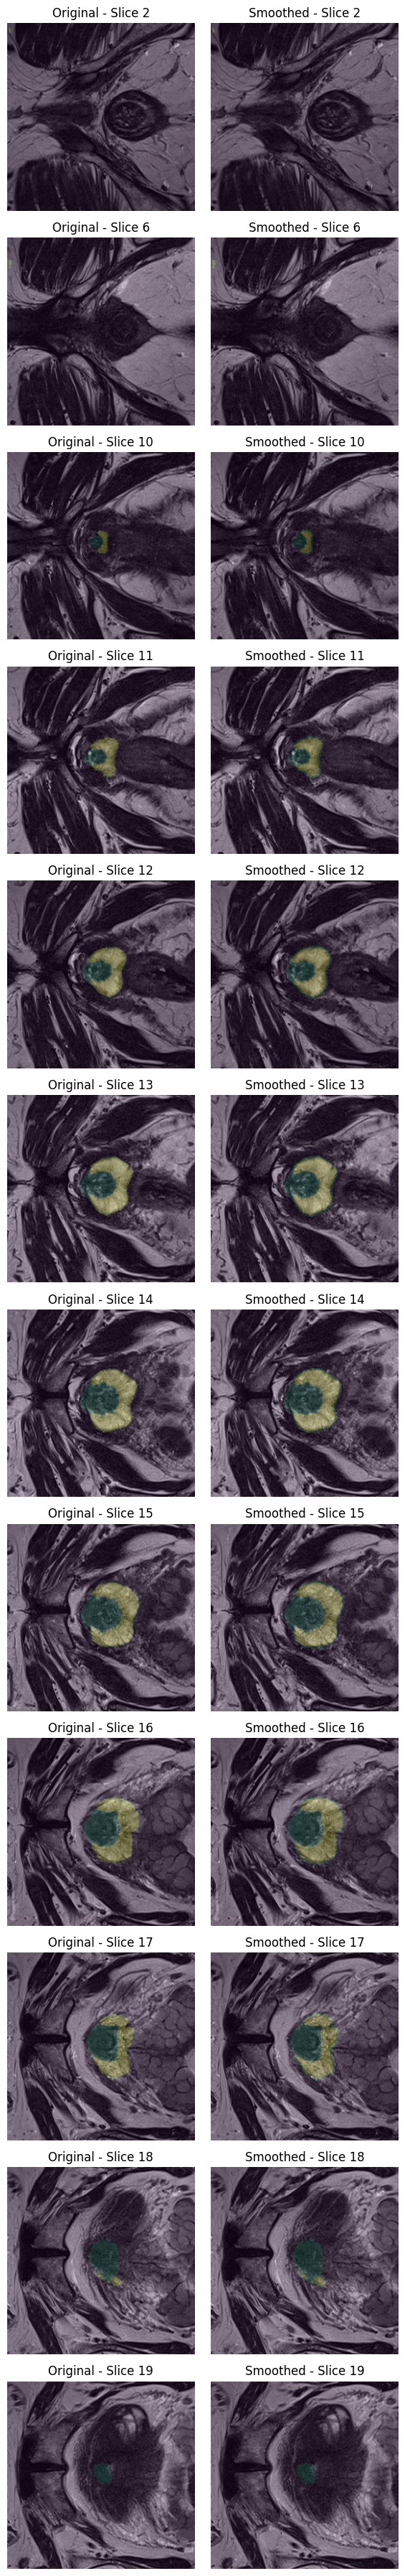

In [13]:
valid_slices = [
    i for i in range(mask.shape[2])
    if np.any(mask[:, :, i] != 0) or np.any(smooth_mask[:, :, i] != 0)
]

vmin, vmax = 0, 2

fig, axes = plt.subplots(len(valid_slices), 2, figsize=(6, 3 * len(valid_slices)))

if len(valid_slices) == 1:
    axes = [axes]

for row, i in enumerate(valid_slices):
    slice_orig = mask[:, :, i]
    slice_smooth = smooth_mask[:, :, i]
    
    # Original
    axes[row][0].imshow(t2[:,:,i], cmap='grey')
    axes[row][0].imshow(slice_orig, cmap='viridis', alpha = 0.2, vmin=vmin, vmax=vmax)
    axes[row][0].set_title(f"Original - Slice {i}")
    axes[row][0].axis('off')
    
    # Smoothed
    axes[row][1].imshow(t2[:,:,i], cmap='grey')
    axes[row][1].imshow(slice_smooth, cmap='viridis', alpha = 0.2, vmin=vmin, vmax=vmax)
    axes[row][1].set_title(f"Smoothed - Slice {i}")
    axes[row][1].axis('off')

plt.tight_layout()
plt.show()

In [17]:
mask_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/prostate_mask'


# Usage
file = os.listdir(mask_dir)[0]
slice = 12
mask = sitk.ReadImage(os.path.join(mask_dir, file))
np_array_og = sitk.GetArrayFromImage(mask)
np_array_og = np_array_og.transpose(1, 2, 0)

mask = sitk.Cast(mask, sitk.sitkFloat32)

# Smooth
smoothed = sitk.DiscreteGaussian(mask, variance=1.5)

# Threshold back to binary
smooth_mask = smoothed > 0.5
smooth_mask = sitk.Cast(smooth_mask, sitk.sitkUInt8)

np_array = sitk.GetArrayFromImage(smooth_mask)
np_array = np_array.transpose(1, 2, 0)
np_array = np.maximum(np_array, np_array_og)



In [20]:
np_array_og, _ = nrrd.read(os.path.join(mask_dir, '0070.nrrd'))
np_array, _ = nrrd.read('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/0070.nrrd')

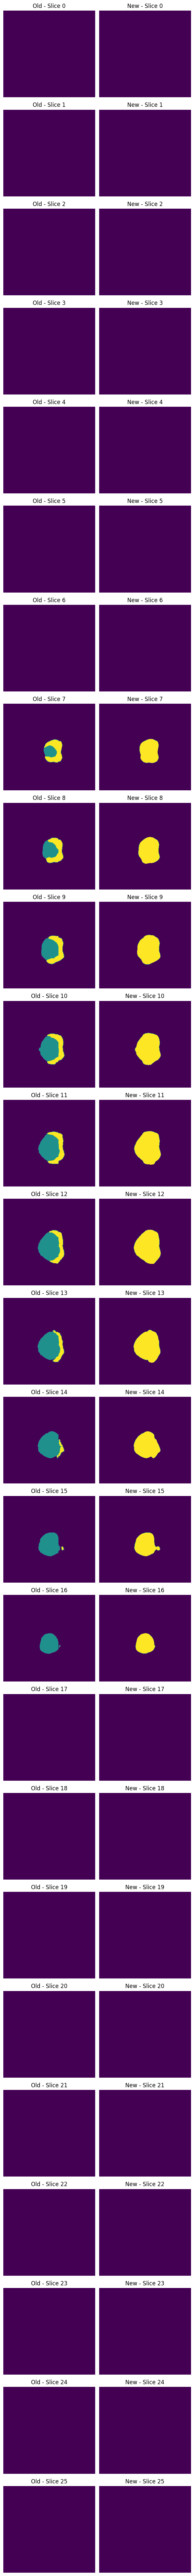

In [21]:
D = np_array_og.shape[2]

fig, axes = plt.subplots(D, 2, figsize=(6, 3 * D))

for i in range(D):
    # Slice along depth
    slice1 = np_array_og[:, :, i]
    slice2 = np_array[:, :, i]
    
    # Column 1: mask1
    axes[i, 0].imshow(slice1, cmap='viridis')
    axes[i, 0].set_title(f"Old - Slice {i}")
    axes[i, 0].axis('off')
    
    # Column 2: mask2
    axes[i, 1].imshow(slice2, cmap='viridis')
    axes[i, 1].set_title(f"New - Slice {i}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [37]:
file

'0026.nrrd'

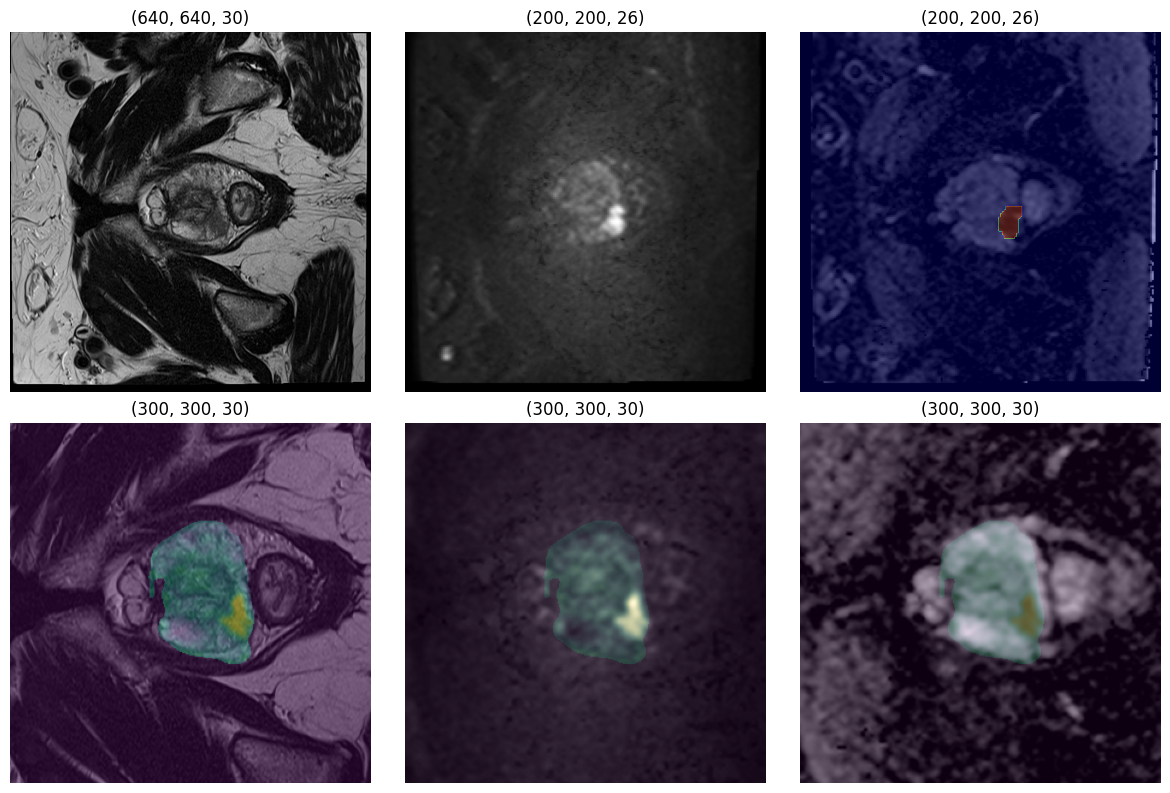

In [41]:
dwi_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/dwi_nrrd/'
adc_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/adc_nrrd/'
adc_mask_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/adc_mask_nrrd/'
t2_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/t2w_nrrd/'
dwi_dir_proc = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/DWI_registered'
adc_dir_proc = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/ADC_clipped/'
t2_dir_proc = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/t2_registered/'
heatmap_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/heatmaps/'
id = 24
file = os.listdir(t2_dir)[id]
t2, _ = nrrd.read(os.path.join(t2_dir,file))
dwi, _ = nrrd.read(os.path.join(dwi_dir,file))
adc, _ = nrrd.read(os.path.join(adc_dir,file))
t2_proc, _ = nrrd.read(os.path.join(t2_dir_proc,file))
dwi_proc, _ = nrrd.read(os.path.join(dwi_dir_proc,file))
adc_proc, _ = nrrd.read(os.path.join(adc_dir_proc,file))#
adc_mask, _ = nrrd.read(os.path.join(adc_mask_dir,file))

heats, _ = nrrd.read(os.path.join(heatmap_dir, file))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
slice = 10
axes[0][0].imshow(t2[:, :, slice], cmap='gray')
axes[0][0].set_title(t2.shape)

axes[0][1].imshow(dwi[:, :, slice], cmap='gray')
axes[0][1].set_title(dwi.shape)

axes[0][2].imshow(adc[:, :, slice], cmap='gray')
axes[0][2].imshow(adc_mask[:, :, slice], cmap='jet', alpha=0.4)
axes[0][2].set_title(adc.shape)

axes[1][0].imshow(t2_proc[:, :, slice], cmap='gray')
axes[1][0].imshow(heats[:, :, slice], cmap='viridis', alpha=0.4)
axes[1][0].set_title(t2_proc.shape)

axes[1][1].imshow(dwi_proc[:, :, slice], cmap='gray')
axes[1][1].imshow(heats[:, :, slice], cmap='viridis', alpha=0.2)
axes[1][1].set_title(dwi_proc.shape)

axes[1][2].imshow(adc_proc[:, :, slice], cmap='gray')
axes[1][2].imshow(heats[:, :, slice], cmap='viridis', alpha=0.2)
axes[1][2].set_title(adc_proc.shape)


for row in axes:
    for ax in row:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [42]:
BasicViewer(heats).show()

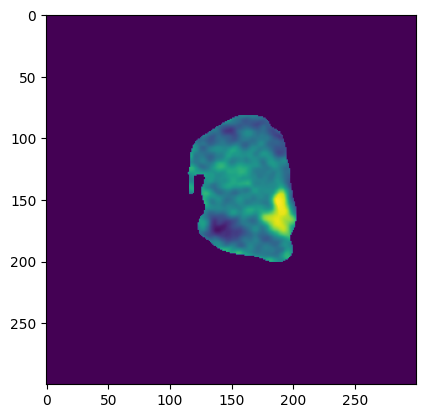

In [30]:
plt.imshow(heats[:, :, slice], cmap='viridis')

In [28]:
BasicViewer(adc, adc_mask).show()

In [2]:
import argparse
import os
from typing import Literal
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch
from monai.data import Dataset, load_decathlon_datalist
from monai.transforms import (
    Compose,
    ConcatItemsd,
    DeleteItemsd,
    EnsureTyped,
    LoadImaged,
    NormalizeIntensityd,
    RandCropByPosNegLabeld,
    RandWeightedCropd,
    ToTensord,
    Transform,
    Transposed,
)
from torch.utils.data.dataloader import default_collate

from src.data.custom_transforms import (
    ClipMaskIntensityPercentilesd,
    ElementwiseProductd,
    NormalizeIntensity_customd,
)


In [3]:
def list_data_collate(batch: list):
    """
    Combine instances from a list of dicts into a single dict, by stacking them along first dim
    [{'image' : 3xHxW}, {'image' : 3xHxW}, {'image' : 3xHxW}...] - > {'image' : Nx3xHxW}
    followed by the default collate which will form a batch BxNx3xHxW
    """

    for i, item in enumerate(batch):
        data = item[0]
        data["image"] = torch.stack([ix["image"] for ix in item], dim=0)

        if all("final_heatmap" in ix for ix in item):
            data["final_heatmap"] = torch.stack([ix["final_heatmap"] for ix in item], dim=0)
            data["smooth_mask"] = torch.stack([ix["smooth_mask"] for ix in item], dim=0)

        batch[i] = data
    return default_collate(batch)


def data_transform(args: argparse.Namespace) -> Transform:
    if args.use_heatmap:
        transform = Compose(
            [
                LoadImaged(
                    keys=["image", "mask", "dwi", "adc", "heatmap", "smooth_mask"],
                    reader="ITKReader",
                    ensure_channel_first=True,
                    dtype=np.float32,
                ),
                ClipMaskIntensityPercentilesd(keys=["image"], lower=0, upper=99.5, mask_key="mask"),
                ConcatItemsd(
                    keys=["image", "dwi", "adc"], name="image", dim=0
                ),  # stacks to (3, H, W)
                NormalizeIntensity_customd(keys=["image"], channel_wise=True, mask_key="mask"),
                ElementwiseProductd(keys=["heatmap", "smooth_mask"], output_key="final_heatmap"),
                RandWeightedCropd(
                    keys=["image", "final_heatmap", "smooth_mask"],
                    w_key="final_heatmap",
                    spatial_size=(args.tile_size, args.tile_size, args.depth),
                    num_samples=args.tile_count,
                ),
                EnsureTyped(keys=["label"], dtype=torch.float32),
                Transposed(keys=["image"], indices=(0, 3, 1, 2)),
                DeleteItemsd(keys=[ "dwi", "adc", "heatmap", "mask"]),
                ToTensord(keys=["image", "label", "final_heatmap", "smooth_mask"]),
            ]
        )
    else:
        transform = Compose(
            [
                LoadImaged(
                    keys=["image", "mask", "dwi", "adc"],
                    reader="ITKReader",
                    ensure_channel_first=True,
                    dtype=np.float32,
                ),
                ClipMaskIntensityPercentilesd(keys=["image"], lower=0, upper=99.5, mask_key="mask"),
                ConcatItemsd(
                    keys=["image", "dwi", "adc"], name="image", dim=0
                ),  # stacks to (3, H, W)
                NormalizeIntensityd(keys=["image"], channel_wise=True),
                RandCropByPosNegLabeld(
                    keys=["image"],
                    label_key="mask",
                    spatial_size=(args.tile_size, args.tile_size, args.depth),
                    pos=1,
                    neg=0,
                    num_samples=args.tile_count,
                ),
                EnsureTyped(keys=["label"], dtype=torch.float32),
                Transposed(keys=["image"], indices=(0, 3, 1, 2)),
                DeleteItemsd(keys=["mask", "dwi", "adc"]),
                ToTensord(keys=["image", "label"]),
            ]
        )
    return transform


def get_dataloader(
    args: argparse.Namespace, split: Literal["train", "test"]
) -> torch.utils.data.DataLoader:

    data_list = load_decathlon_datalist(
        data_list_file_path=args.dataset_json,
        data_list_key=split,
        base_dir=args.data_root,
    )
    print(data_list[0])

    transform = data_transform(args)
    dataset = Dataset(
        data=data_list, transform=transform
    )
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=1,
        shuffle=(split == "train"),
        num_workers=0,
        pin_memory=True,
        multiprocessing_context= None,
        sampler=None,
        collate_fn=list_data_collate,
    )
    return loader


In [33]:
import yaml
from argparse import Namespace

with open("/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/config/config_pirads_train.yaml", "r") as f:
    config_dict = yaml.safe_load(f)

args = Namespace(**config_dict)
args.project_dir = '/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/'
args.run_name = 'dummy'
args.dataset_json = '/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/test_data_updated.json'
args.data_root = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/t2_registered'
args.tile_size = 48

In [34]:
train_loader = get_dataloader(args, split="test")

{'image': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/t2_registered/0070.nrrd', 'mask': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/prostate_mask/0070.nrrd', 'dwi': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/DWI_registered/0070.nrrd', 'adc': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/ADC_clipped/0070.nrrd', 'heatmap': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/heatmaps/0070.nrrd', 'label': 1.0, 'pirads': 4.0, 'smooth_mask': '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/smooth_prostate_mask/0070.nrrd'}


In [35]:
for idx,batch_data in enumerate(train_loader):
    if idx == 20:
        data = batch_data["image"].as_subclass(torch.Tensor)
        target = batch_data["label"].as_subclass(torch.Tensor)
        mask = batch_data["smooth_mask"].as_subclass(torch.Tensor)
        heatmap = batch_data["final_heatmap"].as_subclass(torch.Tensor)
        break


In [43]:
attention_score = torch.zeros((data.shape[0], data.shape[1]))
for i in range(data.shape[0]):
    sample = heatmap[i]
    heatmap_patches = sample.squeeze(1)
    raw_scores_unfil = heatmap_patches.view(len(heatmap_patches), -1).sum(dim=1)

    prostate_mask = mask[i]
    mask_patches = prostate_mask.squeeze(1)
    valid_counts = (mask_patches != 0).sum(dim=(1, 2, 3))

    raw_scores = raw_scores_unfil / valid_counts
    attention_score[i] = raw_scores / raw_scores.sum()
shuffled_images = torch.empty_like(data)
att_labels = torch.empty_like(attention_score)
for i in range(data.shape[0]):
    perm = torch.randperm(data.shape[1])
    shuffled_images[i] = data[i, perm]
    att_labels[i] = attention_score[i, perm]

att_labels[torch.argwhere(target < 1)] = torch.ones_like(att_labels[0]) / len(
    att_labels[0]
)  # For PI-RADS 2, uniform scores across patches


In [44]:
att_labels

tensor([[0.0803, 0.0646, 0.0414, 0.0395, 0.0752, 0.0402, 0.0533, 0.0658, 0.0789,
         0.0850, 0.0392, 0.0976, 0.0603, 0.0556, 0.0771, 0.0459]])

In [45]:
att_labels = att_labels**4  # Sharpening

att_labels = att_labels / att_labels.sum(dim=1, keepdim=True)
att_labels

tensor([[0.1115, 0.0467, 0.0079, 0.0065, 0.0856, 0.0070, 0.0217, 0.0503, 0.1043,
         0.1402, 0.0063, 0.2439, 0.0355, 0.0257, 0.0949, 0.0119]])

In [38]:
t2 = data[0].permute(0,1,3,4,2)
print(t2.shape)
heatmap = heatmap[0]
print(heatmap.shape)


torch.Size([16, 3, 48, 48, 3])
torch.Size([16, 1, 48, 48, 3])


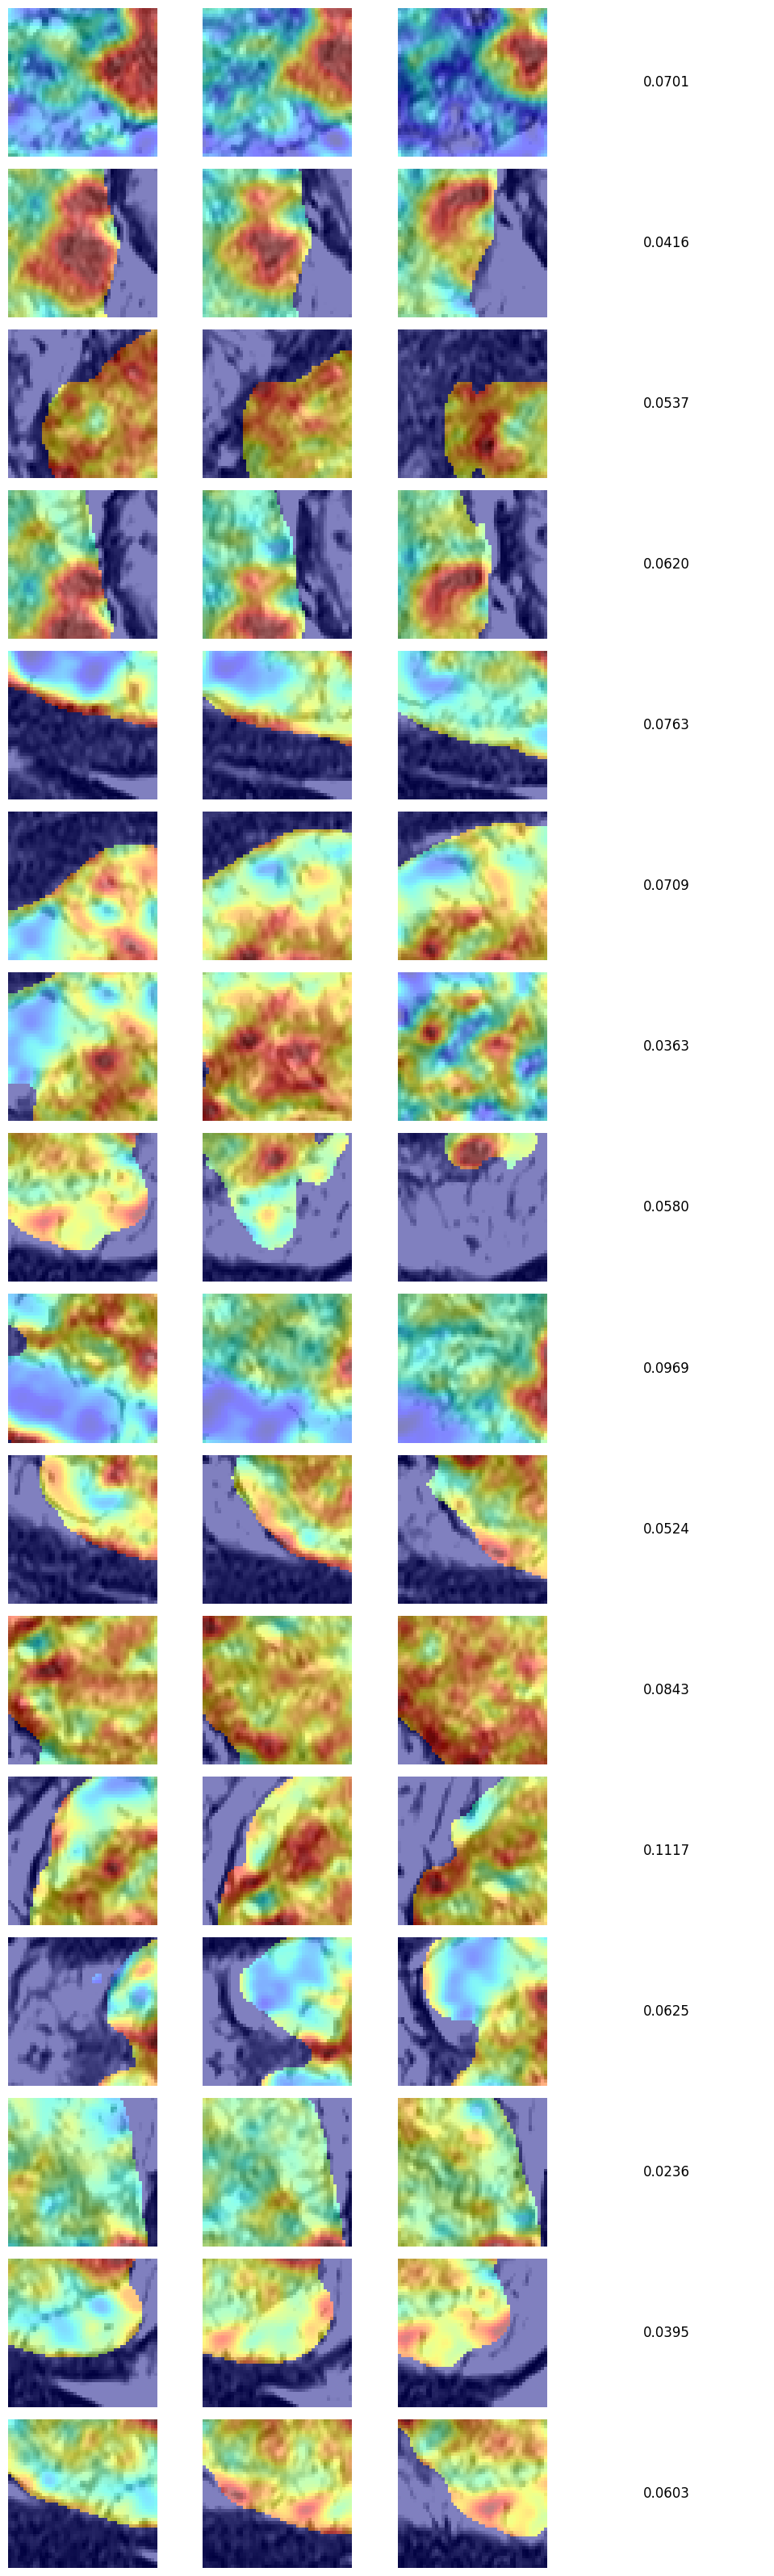

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(16, 4, figsize=(10, 32))

for i in range(16):        # patches (rows)
    for j in range(3):     # channels (columns)
        ax = axes[i, j]
        
        img = t2[i,0, :, :, j].numpy()
        heats = heatmap[i,0, :, :, j].numpy()
        
        ax.imshow(img, cmap='gray')
        ax.imshow(heats, cmap='jet', alpha=0.5)
        ax.axis('off')
    ax_score = axes[i, 3]
    score = att_labels[0][i].item()
    ax_score.text(0.5, 0.5, f"{score:.4f}",
                  ha='center', va='center', fontsize=12)
    ax_score.axis('off')
    

plt.tight_layout()
plt.show()

In [3]:
import os
import numpy as np
import json
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PI-RADS_data.json', 'r') as f:
    data_list = json.load(f)

In [4]:
t2 = os.listdir('/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/t2_nrrd')
dwi = os.listdir('/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/DWI_files_old')
adc = os.listdir('/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/ADC_files_old')

In [5]:
files_train = [i['image'] for i in data_list['train']]
files_test = [i['image'] for i in data_list['test']]
files = files_train + files_test


In [8]:
print(len(files))
print(len(t2), len(dwi), len(adc))

6733
6733 9478 9506


In [10]:
set(t2) == set(files)

True

In [18]:
import os
import nrrd
import numpy as np

def is_continuous(idx):
    idx = sorted(idx)
    return all(b - a == 1 for a, b in zip(idx, idx[1:]))

# Define paths
mask_path = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/prostate_mask'
smooth_mask_path = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/smooth_prostate_mask'

# Create output directories
cropped_mask_path = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/cropped_prostate_mask'
cropped_smooth_mask_path = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/cropped_smooth_prostate_mask'

os.makedirs(cropped_mask_path, exist_ok=True)
os.makedirs(cropped_smooth_mask_path, exist_ok=True)

# Get list of files (assuming same files in both dirs)
files = os.listdir(mask_path)
non_cont = []
for file in tqdm(files):
    if not file.endswith('.nrrd'):
        continue
    
    # Read mask
    mask, header = nrrd.read(os.path.join(mask_path, file))
    
    # Read smooth mask
    smooth_mask, _ = nrrd.read(os.path.join(smooth_mask_path, file))
    

    nonzero_counts = np.count_nonzero(mask, axis=(0, 1))
    top_slices = np.argsort(nonzero_counts)[-10:]
    try:
        assert is_continuous(top_slices), "Top slices are not continuous"
    except AssertionError as e:
        print(f"Top slices for {file} are not continuous: {top_slices}. Proceeding with non-continuous slices.")
        non_cont.append(file)
    cropped_mask = np.zeros_like(mask)
    cropped_mask[:, :, top_slices] = mask[:, :, top_slices]
    cropped_smooth_mask = np.zeros_like(smooth_mask)
    cropped_smooth_mask[:, :, top_slices] = smooth_mask[:, :, top_slices]

    
    # Save cropped masks
    nrrd.write(os.path.join(cropped_mask_path, file), cropped_mask, header)
    nrrd.write(os.path.join(cropped_smooth_mask_path, file), cropped_smooth_mask, header)

  0%|          | 20/6733 [00:02<12:17,  9.10it/s]

Top slices for 41770500_10217114.nrrd are not continuous: [17 18 13 19  7 12  8 11 10  9]. Proceeding with non-continuous slices.


  1%|▏         | 90/6733 [00:11<15:00,  7.38it/s]

Top slices for 48513360_11112885.nrrd are not continuous: [22 21 19 12 18 13 17 14 15 16]. Proceeding with non-continuous slices.


  1%|▏         | 96/6733 [00:12<12:01,  9.19it/s]

...

 99%|█████████▉| 6675/6733 [10:55<00:05, 11.36it/s]

Top slices for 41923682_11342555.nrrd are not continuous: [25 17  9 10 11 12 16 13 14 15]. Proceeding with non-continuous slices.


 99%|█████████▉| 6687/6733 [10:56<00:04, 10.77it/s]

Top slices for 41929826_10771014.nrrd are not continuous: [21 25 20 13 19 14 18 15 16 17]. Proceeding with non-continuous slices.


100%|██████████| 6733/6733 [11:01<00:00, 10.18it/s]


In [19]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PI-RADS_data.json', 'r') as f:
    data = json.load(f)

filtered_train = [i for i in data['train'] if i['image'] not in non_cont]
filtered_test = [i for i in data['test'] if i['image'] not in non_cont]

print(len(data['train']), len(filtered_train))
print(len(data['test']), len(filtered_test))
print(len(non_cont))


        

6057 6011
676 671
51


In [20]:
data['train'] = filtered_train
data['test'] = filtered_test
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PI-RADS_data_updated.json', 'w') as f:
    json.dump(data, f, indent=4)

In [21]:
mask_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/cropped_prostate_mask'
smooth_mask_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/cropped_smooth_prostate_mask'
adc_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/ADC_clipped'
dwi_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/DWI_registered'
heatmap_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/t2_registered'


with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PI-RADS_data_updated.json', 'r') as f:
    data = json.load(f)
    

for i in data['train']:
    i['mask'] = os.path.join(mask_dir, i['image'])
    i['smooth_mask'] = os.path.join(smooth_mask_dir, i['image'])
    i['dwi'] = os.path.join(dwi_dir, i['image'])
    i['adc'] = os.path.join(adc_dir, i['image'])
    i['heatmap'] = os.path.join(heatmap_dir, i['image'])

for i in data['test']:
    i['mask'] = os.path.join(mask_dir, i['image'])
    i['smooth_mask'] = os.path.join(smooth_mask_dir, i['image'])
    i['dwi'] = os.path.join(dwi_dir, i['image'])
    i['adc'] = os.path.join(adc_dir, i['image'])
    i['heatmap'] = os.path.join(heatmap_dir, i['image'])
    




In [22]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PI-RADS_data_updated.json', 'w') as f:
    json.dump(data, f, indent=4)

In [1]:
import argparse
import os
from typing import Literal

import numpy as np
import torch
from monai.data import Dataset, load_decathlon_datalist
from monai.transforms import (
    Compose,
    ConcatItemsd,
    DeleteItemsd,
    EnsureTyped,
    LoadImaged,
    NormalizeIntensityd,
    RandCropByPosNegLabeld,
    RandWeightedCropd,
    ToTensord,
    Transform,
    Transposed,
)
from torch.utils.data.dataloader import default_collate

from src.data.custom_transforms import (
    ClipMaskIntensityPercentilesd,
    ElementwiseProductd,
    NormalizeIntensity_customd,
)

In [2]:
data_list = load_decathlon_datalist(
    data_list_file_path='/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PI-RADS_data_updated.json',
    data_list_key='test',
    base_dir='/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/t2_registered',
)

In [8]:
transform = Compose(
    [
        LoadImaged(
            keys=["image", "mask", "dwi", "adc", "heatmap","smooth_mask"],
            reader="ITKReader",
            ensure_channel_first=True,
            dtype=np.float32,
        ),
        ClipMaskIntensityPercentilesd(keys=["image"], lower=0, upper=99.5, mask_key="mask"),
        ClipMaskIntensityPercentilesd(keys=["dwi"], lower=0, upper=99.5, mask_key="mask"),
        NormalizeIntensity_customd(keys=["image"], mask_key="mask"),
        #NormalizeIntensity_customd(keys=["dwi"], mask_key="mask"),
        ConcatItemsd(
            keys=["image", "dwi", "adc"], name="image", dim=0
        ),  # stacks to (3, H, W)
        ElementwiseProductd(keys=["heatmap", "smooth_mask"], output_key="final_heatmap"),

        EnsureTyped(keys=["label"], dtype=torch.float32),
        Transposed(keys=["image"], indices=(0, 3, 1, 2)),
        DeleteItemsd(keys=[ "adc", "heatmap"]),
        #ToTensord(keys=["image", "label", "final_heatmap", "smooth_mask"]),
    ]
)
dataset__ = Dataset(
    data=data_list, transform=transform, 
)

In [4]:
import os
import numpy as np
import json
import tqdm
import re

In [3]:
with open("/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/preprocessing.log", "r") as f:
    content = f.read()

content

'2026-04-16 09:10:13,930 | INFO | Starting preprocessing\n2026-04-16 09:10:13,938 | INFO | Starting registration and cropping\n2026-04-16 09:57:53,245 | INFO | Starting prostate segmentation\n2026-04-16 09:58:11,840 | WARNING | Top slices for 11152_1001175.nrrd are not continuous: [25  9 10 11 17 12 16 13 14 15]. Proceeding with non-continuous slices.\n2026-04-16 09:58:27,911 | WARNING | Top slices for 11156_1001179.nrrd are not continuous: [ 7  9 10 17 11 12 16 13 15 14]. Proceeding with non-continuous slices.\n2026-04-16 09:58:29,517 | WARNING | Top slices for 11050_1001070.nrrd are not continuous: [36 35 38 11 34 33 12 15 13 14]. Proceeding with non-continuous slices.\n2026-04-16 09:58:38,131 | WARNING | Top slices for 10330_1000336.nrrd are not continuous: [17  7  9 16 15 11 14 12 10 13]. Proceeding with non-continuous slices.\n2026-04-16 09:58:40,305 | WARNING | Top slices for 10670_1000686.nrrd are not continuous: [18  7 10 11 12 13 17 14 15 16]. Proceeding with non-continuous sl

In [6]:
matches = re.findall(r'([\w\/\-.]+\.nrrd)', content)

print(matches)
print(len(matches))

['11152_1001175.nrrd', '11156_1001179.nrrd', '11050_1001070.nrrd', '10330_1000336.nrrd', '10670_1000686.nrrd', '10898_1000914.nrrd', '11465_1001489.nrrd', '10184_1000187.nrrd', '11168_1001191.nrrd', '10932_1000949.nrrd', '10458_1000466.nrrd', '10613_1000627.nrrd', '11166_1001189.nrrd', '11108_1001131.nrrd', '10029_1000029.nrrd', '11351_1001374.nrrd', '11244_1001267.nrrd', '10856_1000872.nrrd', '10551_1000563.nrrd', '10277_1000282.nrrd', '10387_1000393.nrrd', '10812_1000828.nrrd', '10549_1000561.nrrd', '10910_1000927.nrrd', '11380_1001403.nrrd', '10392_1000398.nrrd', '10808_1000824.nrrd', '10818_1000834.nrrd', '10133_1000135.nrrd', '10156_1000159.nrrd', '10581_1000595.nrrd', '11271_1001294.nrrd', '11288_1001311.nrrd', '10966_1000985.nrrd', '11316_1001339.nrrd', '10492_1000501.nrrd', '10274_1000279.nrrd', '11268_1001291.nrrd', '10134_1000136.nrrd', '10289_1000295.nrrd', '10408_1000415.nrrd', '10541_1000552.nrrd', '10874_1000890.nrrd', '10331_1000337.nrrd', '10041_1000041.nrrd', '10569_10

In [7]:
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca.json', 'r') as f:
    data = json.load(f)

In [8]:
mask_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/prostate_mask'
smooth_mask_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/smooth_prostate_mask'
adc_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/ADC_clipped'
dwi_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/DWI_registered'
heatmap_dir = '/sc-projects/sc-proj-cc06-ag-ki-radiologie/pirad_model_test_PICAI/processed/heatmaps'
for i in data['train']:
    i['mask'] = os.path.join(mask_dir, i['image'])
    i['smooth_mask'] = os.path.join(smooth_mask_dir, i['image'])
    i['dwi'] = os.path.join(dwi_dir, i['image'])
    i['adc'] = os.path.join(adc_dir, i['image'])
    i['heatmap'] = os.path.join(heatmap_dir, i['image'])

for i in data['test']:
    i['mask'] = os.path.join(mask_dir, i['image'])
    i['smooth_mask'] = os.path.join(smooth_mask_dir, i['image'])
    i['dwi'] = os.path.join(dwi_dir, i['image'])
    i['adc'] = os.path.join(adc_dir, i['image'])
    i['heatmap'] = os.path.join(heatmap_dir, i['image'])
    
new_train = [i for i in data['train'] if i['image'] not in matches]
new_test = [i for i in data['test'] if i['image'] not in matches]

In [9]:
print(len(new_train), len(new_test))
print(len(data['train']), len(data['test']))
print(len(matches))

644 162
680 170
77


In [10]:
data['train'] = new_train
data['test'] = new_test
with open('/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/PICAI_cspca_updated.json', 'w') as f:
    json.dump(data, f, indent=4)

In [10]:
line.split("VAL loss:")[1].strip().split()

['0.4940', 'AUC:', '0.8232']

In [13]:
with open("/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/logs/cspca_train_new/cspca_train_new.log", "r") as f:
    content = f.read()

#print(content)
train_loss = []
val_loss = []
train_auc = []
val_auc = []

with open("/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/logs/cspca_train_new/cspca_train_new.log", "r") as f:
    for line in f:
        if "TRAIN loss:" in line:
            val = line.split("TRAIN loss:")[1].strip().split()[0]
            train_loss.append(float(val))
            train_auc.append(float(line.split("TRAIN loss:")[1].strip().split()[2]))
        if "VAL loss:" in line:
            val = line.split("VAL loss:")[1].strip().split()[0]
            val_loss.append(float(val))
            val_auc.append(float(line.split("VAL loss:")[1].strip().split()[2]))
            
assert len(train_loss) == len(val_loss) == len(train_auc) == len(val_auc)

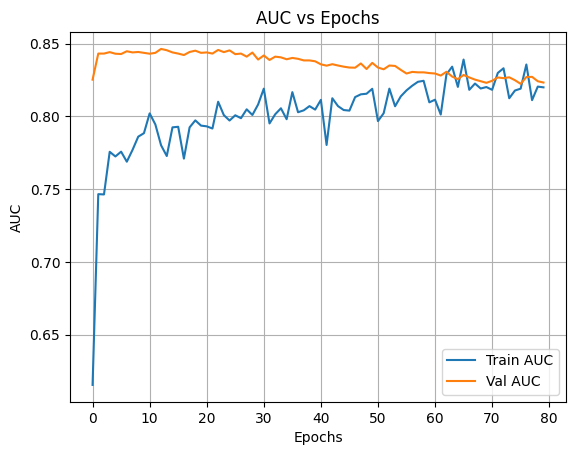

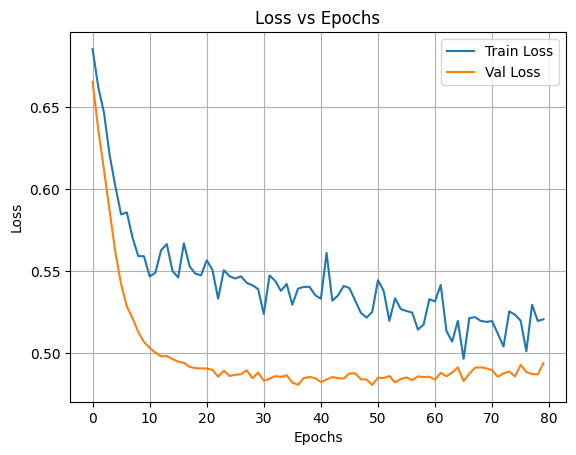

In [17]:
import matplotlib.pyplot as plt

epochs = range(0, len(train_loss) )

# --- AUC Plot ---
plt.figure()
plt.plot(epochs, train_auc, label="Train AUC")
plt.plot(epochs, val_auc, label="Val AUC")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.title("AUC vs Epochs")
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
len(train_loss)

80